KNN(K Nearest Neighbours) classification

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris=load_iris()

In [7]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [8]:
#here firstly sme as svm upto graph bcz we hve sme dataset nd want to classify our data
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [15]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
df['target']=iris.target
df.tail(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [17]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [18]:
df[df.target==1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [19]:
df['flower_name']=df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


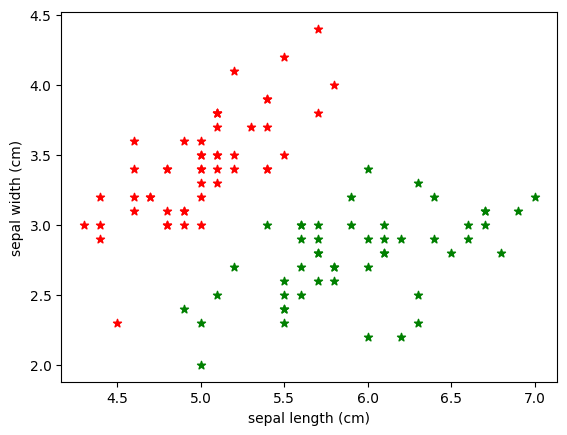

In [8]:
from matplotlib import pyplot as plt
%matplotlib inline
df0=df[df.target==0]
df1=df[df.target==1]
df2=df[df.target==2]

plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],color='red',marker='*')
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],color='green',marker='*')

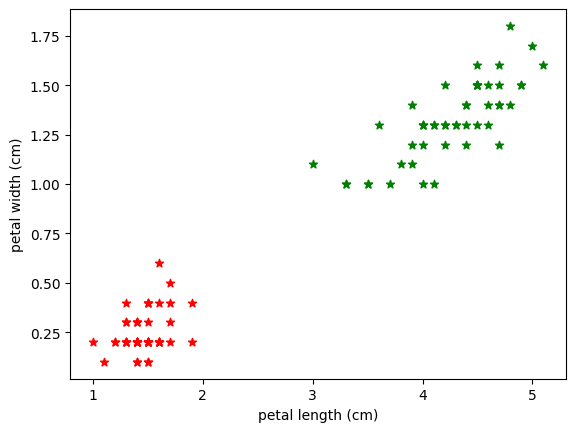

In [9]:
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],color='red',marker='*')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color='green',marker='*')

In [10]:
from sklearn.model_selection import train_test_split
X=df.drop(['target','flower_name'],axis='columns')
X.head(8)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2


In [11]:
y=df.target
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2)
len(X_test)

30

In [12]:
len(X_train)

120

CREATE KNN:---

In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7) #3 is value of k
knn.fit(X_train,Y_train)

NameError: name 'X_train' is not defined

In [22]:
li = []
for i in range(1,10):
    knn=KNeighborsClassifier(n_neighbors=i) #3 is value of k
    knn.fit(X_train,Y_train)
    knn.predict(X_test)
    a = knn.score(X_test,Y_test)
    li.append(a)

print(li)
#to find best value for k we can use gridsearchcv nd k fold method for optimal values of n neighbours
# here the optimal value is 3 but we r using 10 bcz we want to see spme predictions nd chnges

[0.9333333333333333, 0.9, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333]


creating confusion matrix(it tells us that for which classes it got the prediction right)

In [15]:
from sklearn.metrics import confusion_matrix
y_pre=knn.predict(X_test)

cm=confusion_matrix(Y_test,y_pre)
cm


array([[12,  0,  0],
       [ 0,  8,  0],
       [ 0,  2,  8]], dtype=int64)

Text(58.222222222222214, 0.5, 'truth')

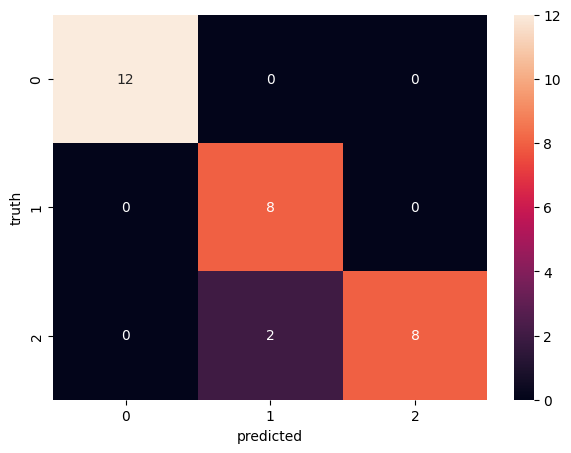

In [16]:
#for better visualization we use seaborn lib of sme confusion matrix
%matplotlib inline
import seaborn as sn
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
sn.heatmap(cm,annot=True)
plt.xlabel('predicted')
plt.ylabel('truth')

#anything on the digonal is the correct prediction i.e 7,10,13
# it stated that the at 0,0 we hve setos flower to be predicted rygt

In [17]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pre))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.80      1.00      0.89         8
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.95      0.93      0.93        30



                                EXERCISE
From sklearn.datasets load digits dataset and do following

Classify digits (0 to 9) using KNN classifier. You can use different values for k neighbors and need to figure out a value of K that gives you a maximum score. You can manually try different values of K or use gridsearchcv
Plot confusion matrix
Plot classification report

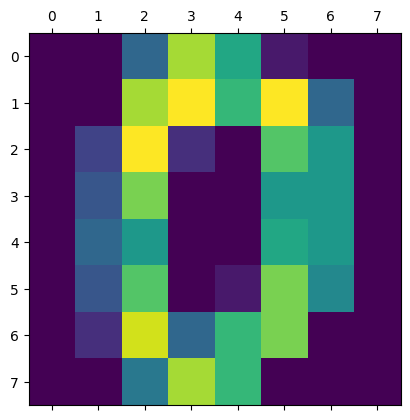

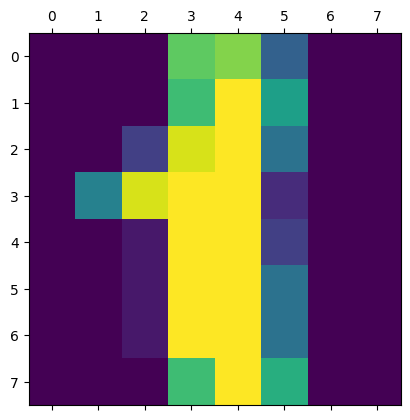

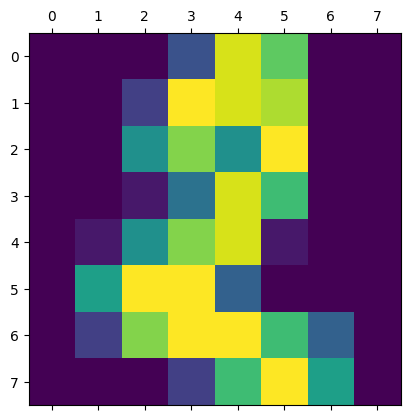

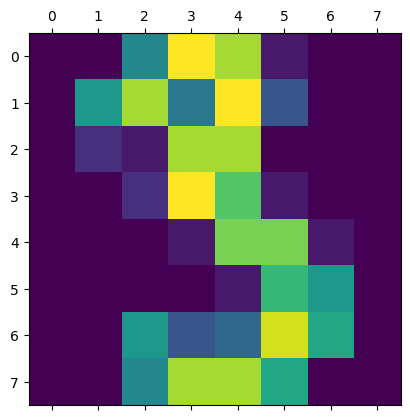

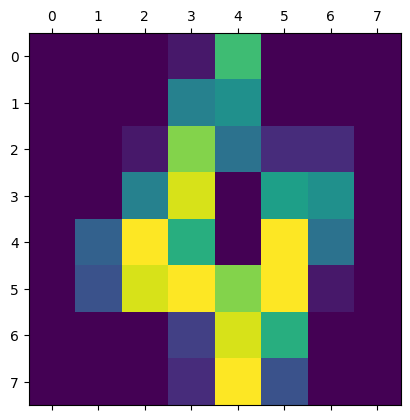

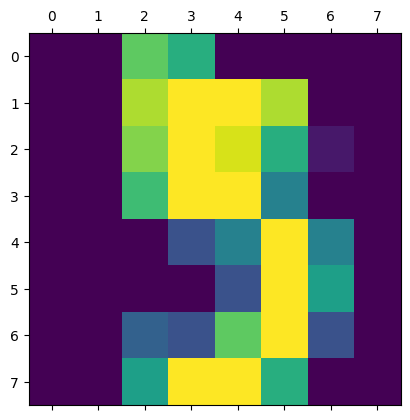

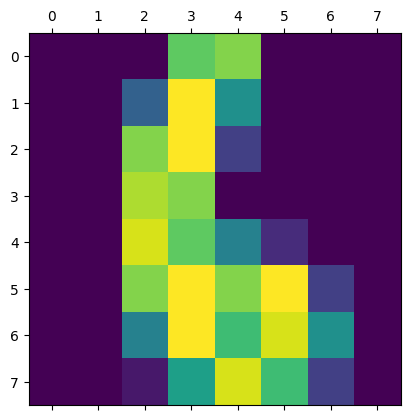

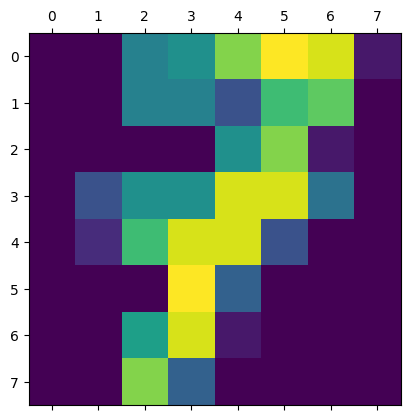

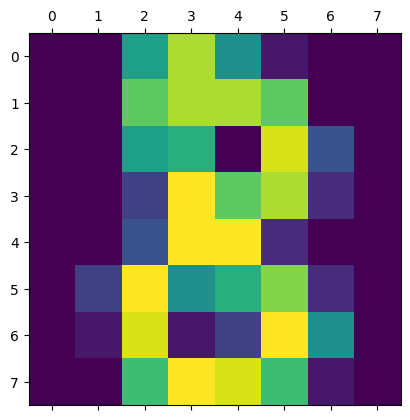

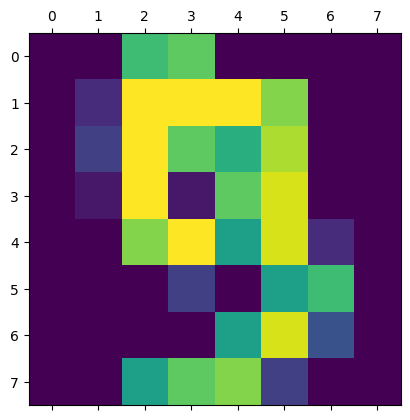

In [18]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.datasets import load_digits
ld=load_digits()
for i in range(0,10):
     plt.matshow(ld.images[i])

In [19]:
from sklearn import train_test_split
x=
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2)

SyntaxError: invalid syntax (3827233592.py, line 2)

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline
warnings.filterwarnings('ignore')

In [4]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.shape

(891, 15)

In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
titanic = titanic[['survived','pclass','sex','age','fare','embarked']]

In [9]:
titanic['age'].fillna(titanic['age'].mean(), inplace=True)
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

In [11]:
X = titanic.drop('survived', axis=1)
y = titanic['survived']